In [852]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [853]:
transportation_emissions = pd.read_csv("../data/transportation_emissions.csv", skiprows=2)
transportation_emissions = transportation_emissions.head(35)
transportation_emissions.columns

Index(['Year', 'Passenger - Cars (megatonnes of carbon dioxide equivalent)',
       'Passenger - Light trucks (megatonnes of carbon dioxide equivalent)',
       'Passenger - Motorcycles, bus, rail, aviation and marine (megatonnes of carbon dioxide equivalent)',
       'Freight - Heavy duty trucks (megatonnes of carbon dioxide equivalent)',
       'Freight - Rail, aviation and marine (megatonnes of carbon dioxide equivalent)',
       'Other (megatonnes of carbon dioxide equivalent)'],
      dtype='str')

In [854]:
transportation_emissions = transportation_emissions.rename(columns= { 'Year' : 'year',
                                                        'Passenger - Cars (megatonnes of carbon dioxide equivalent)' : 'cars',
                                                        'Passenger - Light trucks (megatonnes of carbon dioxide equivalent)' : 'light_trucks',
                                                        'Passenger - Motorcycles, bus, rail, aviation and marine (megatonnes of carbon dioxide equivalent)' : 'passenger_other',
                                                        'Freight - Heavy duty trucks (megatonnes of carbon dioxide equivalent)' : 'heavy_trucks',
                                                        'Freight - Rail, aviation and marine (megatonnes of carbon dioxide equivalent)' : 'freight_other',
                                                        'Other (megatonnes of carbon dioxide equivalent)' : 'other' })
transportation_emissions["total"] = transportation_emissions.drop("year", axis = 1).sum(axis=1)


In [855]:
transportation_emissions["year_over_year"] = (transportation_emissions["total"] - transportation_emissions.shift(1)["total"]).round(2)
transportation_emissions["year_over_year_pct"] = (transportation_emissions["year_over_year"] / transportation_emissions.shift(1)["total"] * 100).round(2)
transportation_emissions.head()

,year,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct
0,1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN
1,1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93
2,1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69
3,1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71
4,1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12


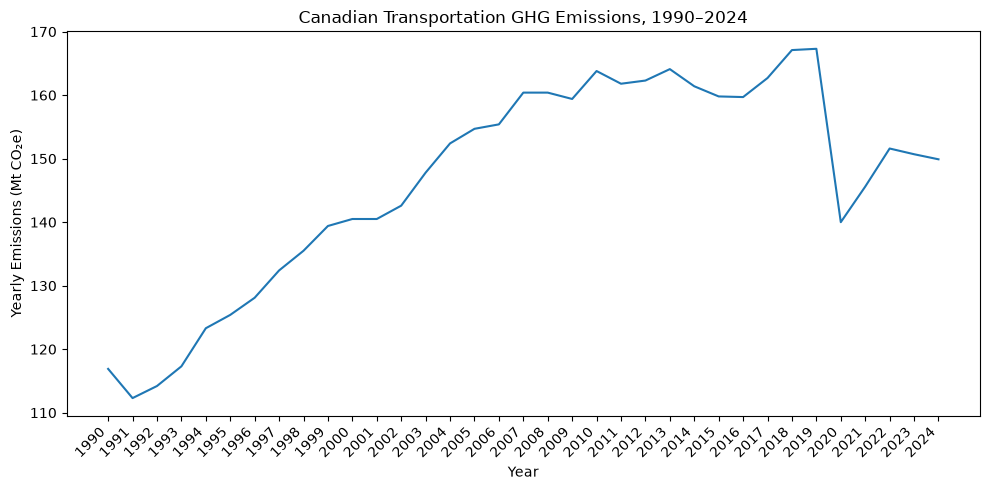

In [856]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(transportation_emissions["year"], transportation_emissions["total"])
ax.set_title("Canadian Transportation GHG Emissions, 1990–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Yearly Emissions (Mt CO₂e)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Questions to answer:

When did emissions peak?

When did the largest increase occur?

In [857]:
peak_year = transportation_emissions.loc[transportation_emissions["total"].idxmax(), "year"]
peak_emissions = transportation_emissions["total"].max()

largest_increase_year = transportation_emissions.loc[transportation_emissions["year_over_year"].idxmax(), "year"]
largest_increase = transportation_emissions["year_over_year"].max()

In [858]:
print(peak_year, peak_emissions, largest_increase, largest_increase_year)

2019 167.3 6.0 1994


Transportation emissions peaked at 167.3 Mt CO₂e in 2019 before declining by 16.3% in 2020. Emissions subsequently recovered, reaching 149.9 Mt CO₂e in 2024.

The largest increases occurred in the 90 with the greatest being in 1994.

Also there was a sharp increase from 2021 onwards with 2022 being roughly equal (+- 0.2) with 1994 for year over year increase.

There was a 27.3 (16.32%) megatonne co2 decrease in 2020.

Recent Trend:

In [859]:
transportation_emissions = transportation_emissions.set_index("year")
emissions_2019_to_2024 = transportation_emissions.at['2024', 'total'] - transportation_emissions.at['2019', "total"]
emissions_2019_to_2024_pct = (transportation_emissions.at['2024', 'total'] - transportation_emissions.at['2019', 'total']) / transportation_emissions.at['2019', 'total'] * 100
emissions_2019_to_2024


np.float64(-17.400000000000034)

In [860]:
emissions_2019_to_2024_pct

np.float64(-10.40047818290498)

There has been a 17.4 (10.4%) megatonne co2 decrease from estimations in 2019 to estimation in 2024.

Whole History:

In [861]:
emissions_1990_to_2024 = transportation_emissions.at['2024', 'total'] - transportation_emissions.at['1990', "total"]
emissions_1990_to_2024_pct = (transportation_emissions.at['2024', 'total'] - transportation_emissions.at['1990', 'total']) / transportation_emissions.at['1990', 'total'] * 100
emissions_1990_to_2024

np.float64(32.999999999999986)

In [862]:
emissions_1990_to_2024_pct

np.float64(28.229255774165946)

There has been a 33.0 (28.22%) megatonne co2 increase from 1990 to 2024.

Long-term Trend:

In [863]:
emissions_1990_to_2019 = transportation_emissions.at['2019', 'total'] - transportation_emissions.at['1990', "total"]
emissions_1990_to_2019_pct = (transportation_emissions.at['2019', 'total'] - transportation_emissions.at['1990', 'total']) / transportation_emissions.at['1990', 'total'] * 100
emissions_1990_to_2019

np.float64(50.40000000000002)

In [864]:
emissions_1990_to_2019_pct

np.float64(43.11377245508984)

There has been a 50.4 (43.11%) megatonne co2 increase from 1990 to 2019.

How have transportation categories changed over time and which are responsible for long-term increases and decreases?

In [865]:
transportation_emissions_flipped = transportation_emissions[["cars", "light_trucks",	"passenger_other",	"heavy_trucks",	"freight_other", "other", "total"]].T

#add faceted visualization of all emission history for each category
transportation_emissions_flipped = transportation_emissions_flipped[["1990", "2024"]]
transportation_emissions_flipped["delta"] = transportation_emissions_flipped["2024"] - transportation_emissions_flipped["1990"]
transportation_emissions_flipped["delta_pct"] = ((transportation_emissions_flipped["2024"] - transportation_emissions_flipped["1990"]) / transportation_emissions_flipped["1990"] * 100).round(2)
transportation_emissions_flipped = transportation_emissions_flipped.reset_index()
transportation_emissions_flipped = transportation_emissions_flipped.rename(columns= {"index" : "categories"})
transportation_emissions_flipped

year,categories,1990,2024,delta,delta_pct
0,cars,44.8,24.2,-20.6,-45.98
1,light_trucks,25.9,55.0,29.1,112.36
2,passenger_other,9.0,12.3,3.3,36.67
3,heavy_trucks,19.2,35.7,16.5,85.94
4,freight_other,9.8,9.0,-0.8,-8.16
5,other,8.2,13.7,5.5,67.07
6,total,116.9,149.9,33.0,28.23


From the table we can see that the amount of emissions from cars has decreased by nearly 50%

The emissions from light trucks has more than doubled.

The emissions from heavy trucks has increased signicantly from 1990.

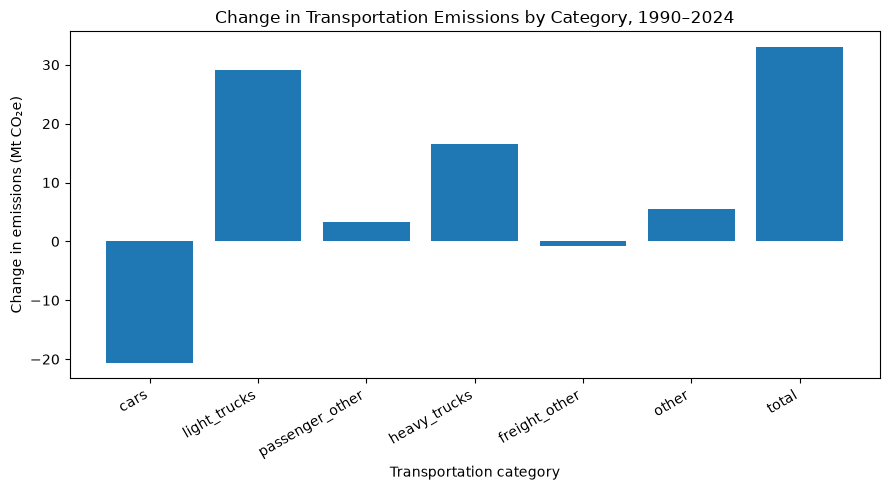

In [866]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(transportation_emissions_flipped["categories"], transportation_emissions_flipped["delta"])
ax.set_title("Change in Transportation Emissions by Category, 1990–2024")
ax.set_xlabel("Transportation category")
ax.set_ylabel("Change in emissions (Mt CO₂e)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

How has the composition of transportation emissions changed?

In [867]:
transportation_emissions_narrow = transportation_emissions.reset_index()[["year", "cars", "light_trucks",	"passenger_other",	"heavy_trucks",	"freight_other","other"]]
transportation_emissions_narrow = transportation_emissions_narrow.melt(id_vars="year", var_name="category", value_name="emissions").sort_values("year")
transportation_emissions_narrow["pct_total"] = (transportation_emissions_narrow["emissions"] / transportation_emissions_narrow.groupby("year")["emissions"].transform("sum") * 100).round(2)
transportation_emissions_narrow.groupby("year").head(20)
transportation_emissions_narrow_pivoted = transportation_emissions_narrow.pivot(index=["year"], columns="category", values="pct_total")
transportation_emissions_narrow_pivoted

category,cars,freight_other,heavy_trucks,light_trucks,other,passenger_other
year,,,,,,
1990,38.32,8.38,16.42,22.16,7.01,7.70
1991,38.74,8.73,15.85,22.71,6.86,7.12
1992,38.70,8.32,16.02,23.20,6.74,7.01
1993,38.53,8.18,16.37,23.61,6.65,6.65
1994,37.31,8.19,17.36,23.76,6.73,6.65
1995,35.49,8.05,18.10,23.76,7.74,6.86
1996,34.58,7.81,18.35,24.28,7.88,7.10
1997,33.16,7.63,19.03,24.77,8.31,7.10
1998,32.25,7.31,18.97,25.61,8.71,7.16


We see that the proportion of emissions from cars has decreased since 1990.

Conversely we see that the proportion of emissions by light trucks has increased.

Follow up question: How has the proportion of emissions from freight vs passenger vehicles compare?

In [868]:
transportation_emissions_narrow_pivoted["passenger"] = transportation_emissions_narrow_pivoted["cars"] + transportation_emissions_narrow_pivoted["light_trucks"] + transportation_emissions_narrow_pivoted["passenger_other"]
transportation_emissions_narrow_pivoted["freight"] = transportation_emissions_narrow_pivoted["freight_other"] + transportation_emissions_narrow_pivoted["heavy_trucks"]
transportation_emissions_passenger_vs_freight = transportation_emissions_narrow_pivoted[["passenger", "freight", "other"]]
transportation_emissions_narrow_pivoted = transportation_emissions_narrow_pivoted[["cars", "light_trucks", "passenger_other", "heavy_trucks",	"freight_other","other"]]
transportation_emissions_passenger_vs_freight

category,passenger,freight,other
year,,,
1990,68.18,24.80,7.01
1991,68.57,24.58,6.86
1992,68.91,24.34,6.74
1993,68.79,24.55,6.65
1994,67.72,25.55,6.73
1995,66.11,26.15,7.74
1996,65.96,26.16,7.88
1997,65.03,26.66,8.31
1998,65.02,26.28,8.71


We can see that the proportion of emissions contributed by passenger vehicles has decreased  and the proportion of emissions contributed by freight vehicles has increased since 1990.

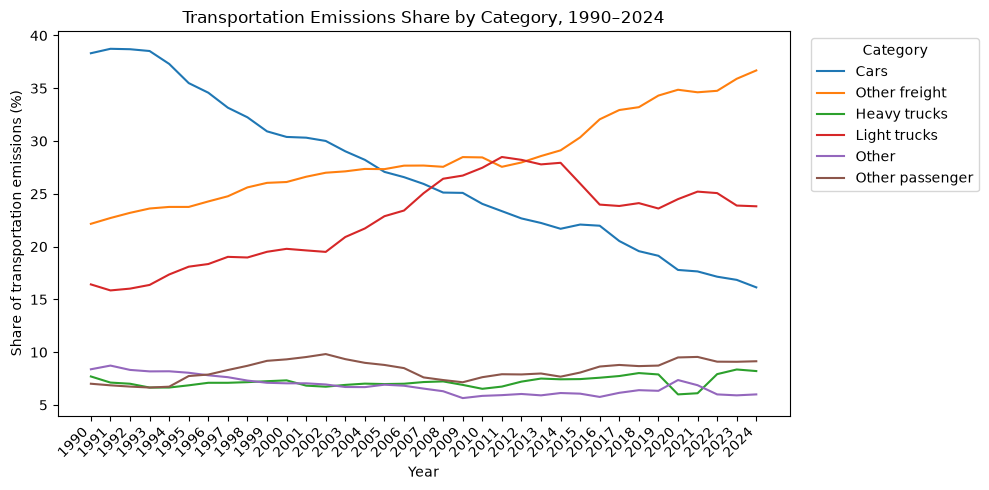

In [869]:
fig, ax = plt.subplots(figsize=(10, 5))

categories = ["Cars", "Other freight", "Heavy trucks", "Light trucks", "Other", "Other passenger"]

ax.plot(transportation_emissions_narrow_pivoted, label=categories)
ax.set_xlabel("Year")
ax.set_ylabel("Share of transportation emissions (%)")
ax.set_title("Transportation Emissions Share by Category, 1990–2024")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

How has Canada's emission production changed on a per capita level?

In [870]:
population = pd.read_csv("../data/population_data.csv")
population = population.rename(columns= {"Unnamed: 0" : "year", "Population" : "population"})
population = population[population["year"].between(1990, 2024)]
population = population.set_index("year")

In [871]:
transportation_emissions.index = transportation_emissions.index.astype(int)
transportation_emissions = transportation_emissions.join(population, how='left')
transportation_emissions.style.format( {'population' : '{:.2e}'})
transportation_emissions

,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population
year,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812


In [872]:
transportation_emissions["emissions_per_capita"] = (transportation_emissions["total"] * pow(10, 6)  / transportation_emissions["population"]).round(2) #emissions now in tonnes
transportation_emissions

,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population,emissions_per_capita
year,,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204,4.23
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761,4.01
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641,4.03
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166,4.09
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189,4.25
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423,4.28
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849,4.33
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752,4.43
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812,4.49


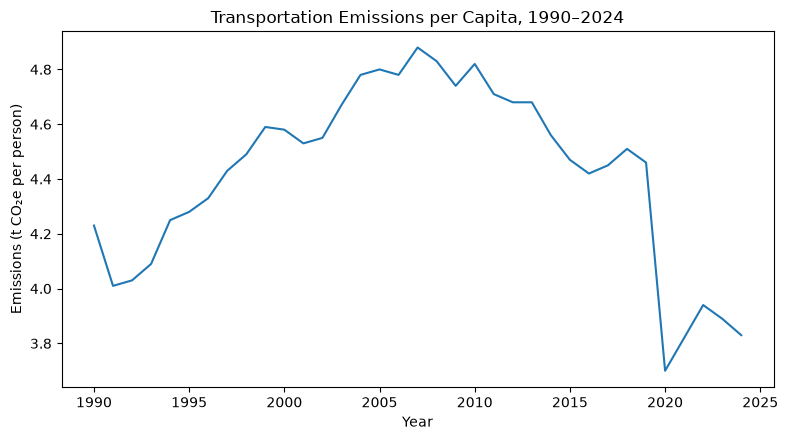

In [873]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(transportation_emissions.index, transportation_emissions["emissions_per_capita"])
ax.set_title("Transportation Emissions per Capita, 1990–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Emissions (t CO₂e per person)")
plt.tight_layout()
plt.show()

Although total transportation emissions increased substantially between 1990 and 2019, transportation emissions per capita peaked in 2007 and subsequently declined. 

This suggests that population growth alone does not explain the long-term increase in total transportation emissions.

Although it is fair to assume some of the year to year increases in emissions can be attributed to a growing population

Some other possible variables to explore:
- **fuel consumption
- fuel prices
- **vehicle efficiency
- EV adoption and switch to electric
- **GDP

How are GDP and transportation emissions related?


In [874]:
gdp = pd.read_csv("../data/canadian_gdp.csv", skiprows=10)
gdp = gdp[gdp["Estimates"] == "Gross domestic product at market prices"]
gdp = gdp.T.drop("Estimates")
gdp = gdp.rename(columns={1 : 'gdp',})
gdp.index = gdp.index.astype(int)
transportation_emissions = transportation_emissions.join(gdp, how="left")
transportation_emissions["gdp"] = transportation_emissions["gdp"].str.replace(",", "").astype(int)
transportation_emissions



,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population,emissions_per_capita,gdp
year,,,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204,4.23,1159666
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761,4.01,1135417
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641,4.03,1145527
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166,4.09,1175972
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189,4.25,1228821
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423,4.28,1261782
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849,4.33,1283093
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752,4.43,1338011
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812,4.49,1390098


In [875]:
transportation_emissions["emissions_per_gdp"] = transportation_emissions["total"] * pow(10, 6) / transportation_emissions["gdp"] #units is tonnes of CO2 eq / million $CAD
transportation_emissions

,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population,emissions_per_capita,gdp,emissions_per_gdp
year,,,,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204,4.23,1159666,100.804887
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761,4.01,1135417,98.906393
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641,4.03,1145527,99.692107
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166,4.09,1175972,99.747273
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189,4.25,1228821,100.340082
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423,4.28,1261782,99.383253
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849,4.33,1283093,99.836879
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752,4.43,1338011,98.952849
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812,4.49,1390098,97.475142


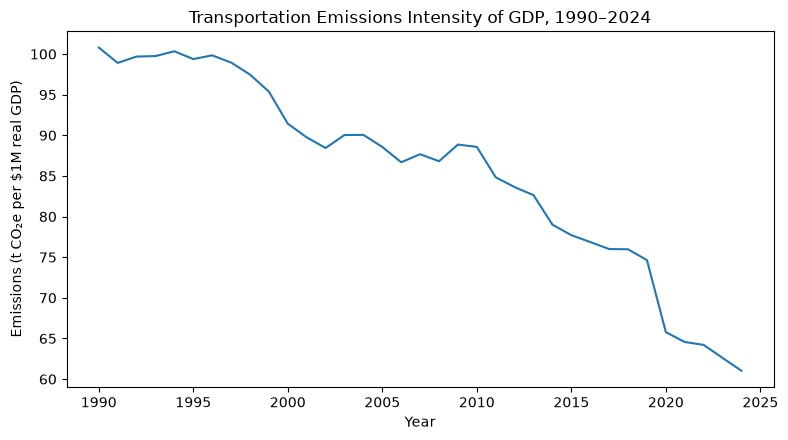

In [876]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(transportation_emissions.index, transportation_emissions["emissions_per_gdp"])
ax.set_title("Transportation Emissions Intensity of GDP, 1990–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Emissions (t CO₂e per $1M real GDP)")
plt.tight_layout()
plt.show()

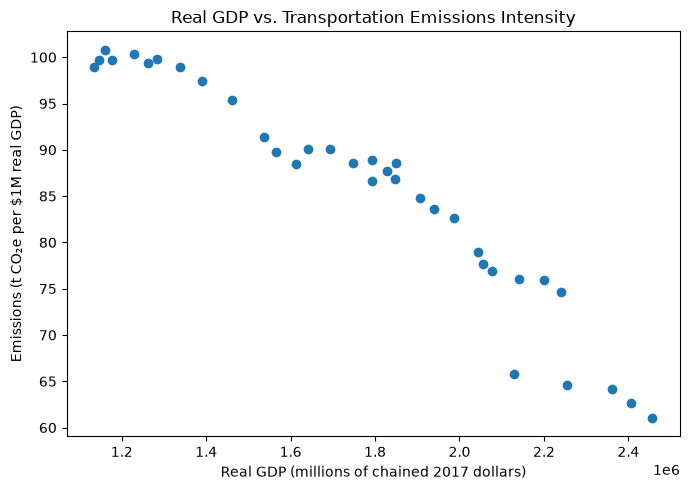

In [877]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(transportation_emissions["gdp"], transportation_emissions["emissions_per_gdp"])
ax.set_title("Real GDP vs. Transportation Emissions Intensity")
ax.set_xlabel("Real GDP (millions of chained 2017 dollars)")
ax.set_ylabel("Emissions (t CO₂e per $1M real GDP)")
plt.tight_layout()
plt.show()

Transportation emissions intensity of GDP declined substantially over the period, indicating that transportation emissions grew more slowly than Canada's economic output.\

How have new-vehicle fuel efficiency ratings changed over time, and how do these trends compare with light-duty vehicle emissions?

In [878]:
fuel_efficiency = pd.read_csv("../data/1995-2014_fuel_consumption.csv")
fuel_efficiency_cont = pd.read_csv("../data/2015-2024_fuel_consumption.csv")
fuel_efficiency = pd.concat([fuel_efficiency, fuel_efficiency_cont])
fuel_efficiency = fuel_efficiency.groupby("Model year")[["City (L/100 km)", "Highway (L/100 km)", "Combined (L/100 km)", "CO2 emissions (g/km)"]].mean()
fuel_efficiency

,City (L/100 km),Highway (L/100 km),Combined (L/100 km),CO2 emissions (g/km)
Model year,,,,
1995,15.083671,11.059356,13.272110,307.663886
1996,14.624069,10.615759,12.821633,296.176218
1997,14.646049,10.588298,12.818693,295.861702
1998,14.793691,10.637382,12.927129,297.990536
1999,14.711628,10.646802,12.882849,295.562500
2000,14.705956,10.699373,12.905016,296.642633
2001,14.591900,10.613844,12.802798,293.656848
2002,15.065946,10.997297,13.234459,300.747297
2003,14.905366,10.881707,13.096220,298.147561


It should be noted that the averages for fuel efficiency here are taken across every vehicle without accounting for fleet distribution. It is simply the average for every manufactured vehicle model each year.

The average rated fuel consumption of vehicle models declined substantially from 1995 through the mid-2010s, indicating improvements in the efficiency of new light-duty vehicle models. 

However, these averages are not weighted by vehicle sales or fleet composition and therefore should not be interpreted as the efficiency of Canada's vehicle fleet.

This analysis provides contextual evidence about technological efficiency improvements rather than a direct estimate of their effect on national transportation emissions

In [879]:
transportation_emissions = transportation_emissions.join(fuel_efficiency, how='left')
transportation_emissions["light_duty"] = transportation_emissions["cars"] + transportation_emissions["light_trucks"]
transportation_emissions

,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population,emissions_per_capita,gdp,emissions_per_gdp,City (L/100 km),Highway (L/100 km),Combined (L/100 km),CO2 emissions (g/km),light_duty
year,,,,,,,,,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204,4.23,1159666,100.804887,NaN,NaN,NaN,NaN,70.7
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761,4.01,1135417,98.906393,NaN,NaN,NaN,NaN,69.0
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641,4.03,1145527,99.692107,NaN,NaN,NaN,NaN,70.7
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166,4.09,1175972,99.747273,NaN,NaN,NaN,NaN,72.9
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189,4.25,1228821,100.340082,NaN,NaN,NaN,NaN,75.3
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423,4.28,1261782,99.383253,15.083671,11.059356,13.272110,307.663886,74.3
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849,4.33,1283093,99.836879,14.624069,10.615759,12.821633,296.176218,75.4
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752,4.43,1338011,98.952849,14.646049,10.588298,12.818693,295.861702,76.7
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812,4.49,1390098,97.475142,14.793691,10.637382,12.927129,297.990536,78.4


How are all these different variable that have been explored correlated?

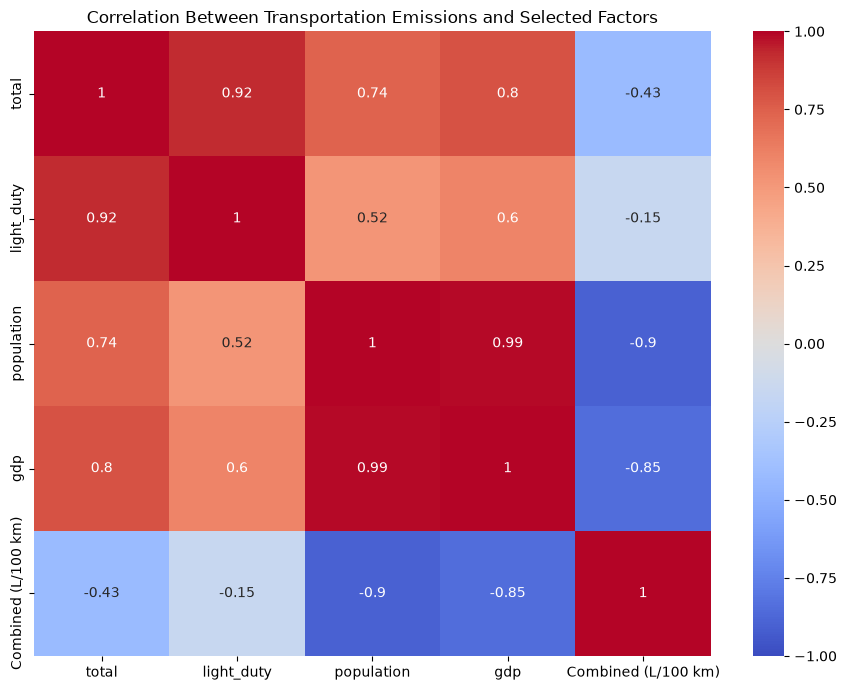

In [880]:
matrix = transportation_emissions[["total", "light_duty", "population", "gdp", "Combined (L/100 km)"]].corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Transportation Emissions and Selected Factors")
plt.tight_layout()
plt.show()

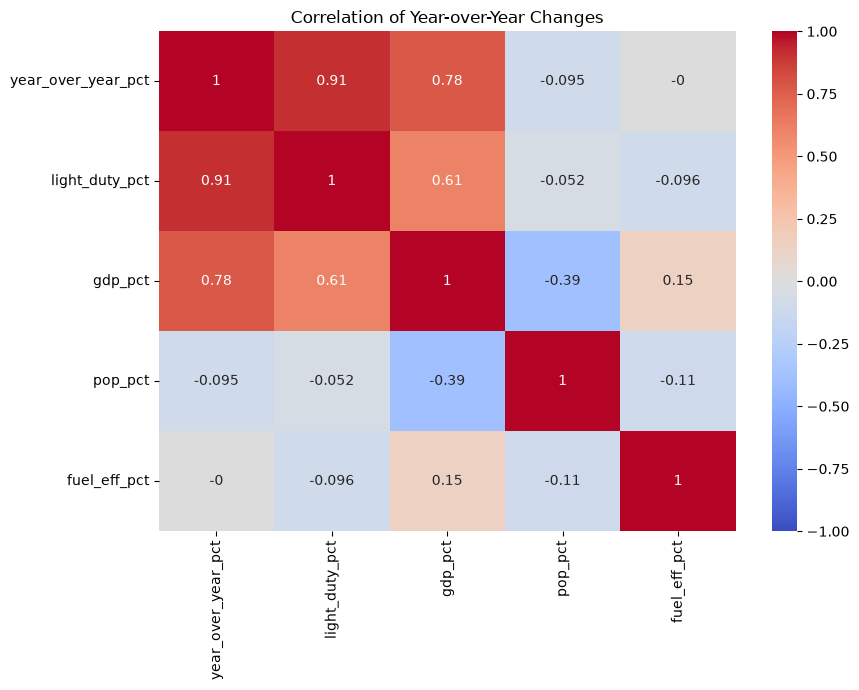

In [881]:
year_over_year = transportation_emissions[["cars", "light_trucks", "light_duty", "year_over_year_pct", "gdp", "population", "Combined (L/100 km)"]].copy()
year_over_year["light_duty_pct"] = (year_over_year["light_duty"] - year_over_year["light_duty"].shift(1)) / year_over_year["light_duty"].shift(1)
year_over_year["gdp_pct"] = (year_over_year["gdp"] - year_over_year["gdp"].shift(1)) / year_over_year["gdp"].shift(1)
year_over_year["pop_pct"] = (year_over_year["population"] - year_over_year["population"].shift(1)) / year_over_year["population"].shift(1)
year_over_year["fuel_eff_pct"] = (year_over_year["Combined (L/100 km)"] - year_over_year["Combined (L/100 km)"].shift(1)) / year_over_year["Combined (L/100 km)"].shift(1)
year_over_year = year_over_year[["year_over_year_pct", "light_duty_pct", "gdp_pct", "pop_pct", "fuel_eff_pct"]]

year_over_year_matrix = year_over_year.corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(year_over_year_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Year-over-Year Changes")
plt.tight_layout()
plt.show()

By using percentage change, it can be seen that previously correlated variables are no longer very correlated, likely because they followed a similar trend.

We see that out of all the variable looked at, it seems GDP is the most correlated variable for transit emissions output using a percentage change method.

However, it should be noted that response variable may "lag" or take time to be affected by explanatory variables, and percentage change does not capture that.


This outcome poses more questions for investigation such as:

Do people drive less during economic hardships?



In [882]:
variables = ["gdp", "population", "light_duty", "Combined (L/100 km)"]

results = []

for variable in variables:
    for lag in range(6):
        correlation = transportation_emissions["total"].corr(transportation_emissions[variable].shift(lag))

        results.append({
            "variable": variable,
            "lag": lag,
            "correlation": correlation
        })

lag_corr = pd.DataFrame(results)

#lag_corr

Across the lag periods tested, correlations were generally similar, with the strongest correlations occurring at a lag of zero years.

However, because variables such as GDP and population change gradually over time, shifting them by a few years does not substantially alter their overall trends.

 As a result, the lag analysis provides limited evidence for distinguishing immediate from delayed relationships with transportation emissions.

However, these correlations represent associations and do not establish a causal relationship between the factors and transportation emissions.